# Terra Climate Sample Notebook                 

This notebooks demonstrates how to access the TerraClimate dataset and how to create a local GeoTIFF file. TerraClimate is a dataset of monthly climate and climatic water balance for global terrestrial surfaces from 1958 to the present. These data provide important inputs for ecological and hydrological studies at global scales that require high spatial resolution and time-varying data. All data have monthly temporal resolution and a ~4-km (1/24th degree) spatial resolution. This dataset is provided in Zarr format.

For more information, visit: https://planetarycomputer.microsoft.com/dataset/terraclimate#overview

## Load Python Dependencies

In [1]:
# Install missing packages
# !pip install rioxarray pystac-client planetary-computer zarr adlfs --quiet

In [2]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')



# Import common GIS tools
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rio
import rasterio
from matplotlib.cm import jet
import pandas as pd

# Import Planetary Computer tools
import pystac_client
import planetary_computer


from tqdm import tqdm

## Loading TerraClimate Data

In [3]:
# Access STAC catalog and collection.
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace)

collection = catalog.get_collection("terraclimate")
asset = collection.assets["zarr-abfs"]

In [4]:
asset.extra_fields["xarray:open_kwargs"]

{'chunks': {},
 'engine': 'zarr',
 'consolidated': True,
 'storage_options': {'account_name': 'cpdataeuwest',
  'credential': 'st=2026-04-14T11%3A56%3A25Z&se=2026-04-15T12%3A41%3A25Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-04-13T10%3A18%3A19Z&ske=2026-04-20T10%3A18%3A19Z&sks=b&skv=2025-07-05&sig=L%2BMJrK0Rc0FbtNfcpofHf5k5U%2BsRNPccR8JtK9HDhWc%3D'}}

In [5]:
# Open dataset and remove CRS.
ds = xr.open_dataset(asset.href,**asset.extra_fields["xarray:open_kwargs"])
# ds = ds.drop('crs', dim=None) # Remove the CRS coordinate in the dataset
# ds

A list of the available parameters is shown below:
![image.png](attachment:572022af-ed73-4ad2-bf78-e9db3b2bfc55.png)

In [6]:
# Get the total memory usage in bytes
total_bytes = ds.nbytes

# Print the memory usage in a common format
print(f"Total memory usage: {total_bytes / 1024**2 / 1024:.0f} GB")

Total memory usage: 1815 GB


In [ ]:
# Since this is a HUGE dataset (nearly 2 TB), we should parse the dataset
# Trimming dataset to years 2017 thru 2019
# ds = ds.sel(time=slice("2017-11-01", "2019-11-01"))

In [ ]:
# Trimming dataset to the desired Lat-Lon bounds (southeastern Australia)

min_lon = 139.94
min_lat = -39.74
max_lon = 151.48
max_lat = -30.92

mask_lon = (ds.lon >= min_lon) & (ds.lon <= max_lon)
mask_lat = (ds.lat >= min_lat) & (ds.lat <= max_lat)

In [9]:
# Crop the dataset to smaller Lat-Lon regions
ds = ds.where(mask_lon & mask_lat, drop=True)
ds

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 768, lat: 212, lon: 277, crs: 1)
Coordinates:
  * crs      (crs) int16 2B 3
  * lat      (lat) float64 2kB -30.94 -30.98 -31.02 ... -39.65 -39.69 -39.73
  * lon      (lon) float64 2kB 140.0 140.0 140.1 140.1 ... 151.4 151.4 151.5
  * time     (time) datetime64[ns] 6kB 1958-01-01 1958-02-01 ... 2021-12-01
Data variables: (12/14)
    aet      (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    def      (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    pdsi     (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    pet      (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    ppt      (time, lat, lon) float64 361MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    q        (time, lat, lon) float64 361MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    ...       ...
    swe      (time, lat, lon) float64 361MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    tmax     (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    tmin     (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    vap      (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    vpd      (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
    ws       (time, lat, lon) float32 180MB dask.array<chunksize=(12, 212, 277), meta=np.ndarray>
Attributes: (12/52)
    Conventions:                     CF-1.6
    acknowledgment:                  Please cite the references included here...
    cdm_data_type:                   GRID
    contributor_email:               khegewisch@ucmerced.edu
    contributor_name:                Katherine Hegewisch
    contributor_role:                Postdoctoral Fellow
    ...                              ...
    time_coverage_duration:          P1Y
    time_coverage_end:               1958-12-01T00:0
    time_coverage_resolution:        P1M
    time_coverage_start:             1958-01-01T00:0
    title:                           TerraClimate: monthly climate and climat...
    version:                         v1.0

In [10]:
total_bytes = ds.nbytes

# Print the memory usage in a common format
print(f"Total memory usage: {total_bytes / 1024**2 / 1024:.0f} GB")

Total memory usage: 3 GB


In [13]:
ds.lon

<xarray.DataArray 'lon' (lon: 277)> Size: 2kB
array([139.979167, 140.020833, 140.0625  , ..., 151.395833, 151.4375  ,
       151.479167], shape=(277,))
Coordinates:
  * lon      (lon) float64 2kB 140.0 140.0 140.1 140.1 ... 151.4 151.4 151.5
Attributes:
    axis:           X
    description:    Longitude of the center of the grid cell
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east

In [ ]:
ds.soil.sel(lat=-30.9375, lon=139.979167, method="nearest")

(768,)

: 

In [25]:
# Get the total memory usage in bytes
total_bytes2 = ds.nbytes

# Print the memory usage in a common format ... notice it is MUCH smaller now!
print(f"Total memory usage: {total_bytes2 / 1024**2:.0f} MB")

Total memory usage: 95 MB


## Exploring the Data

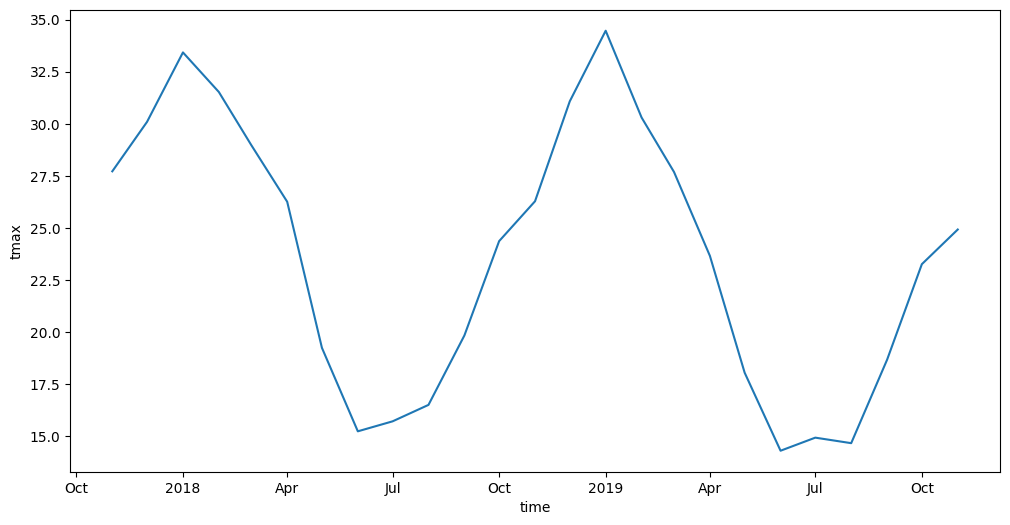

In [35]:
# Plot mean temperature over the region for 2 years
# This will demonstrate the expected seasonal variation
temperature = ds["tmax"].mean(dim=["lat", "lon"])
temperature.plot(figsize=(12, 6));

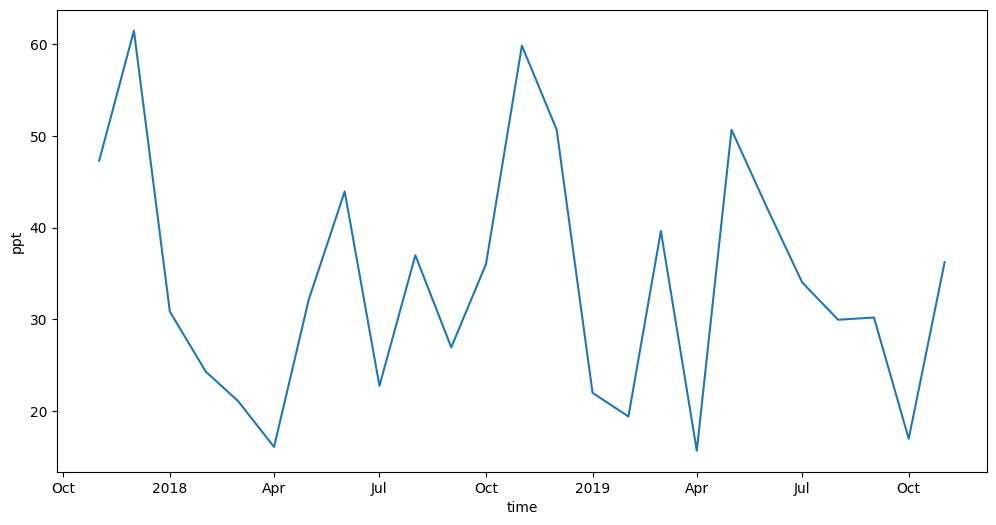

In [36]:
# Plot monthly accumulated precipitation over the region for 2 years
temperature = ds["ppt"].mean(dim=["lat", "lon"])
temperature.plot(figsize=(12, 6));

In [37]:
# Calculate the median of the dataset over time
soil_median = ds.soil.median(dim="time").compute()

In [32]:
ds.soil.values

array([[[0.       , 0.       , 0.       , ..., 7.3      , 7.7000003,
         7.6      ],
        [0.       , 0.       , 0.       , ..., 6.9      , 7.8      ,
         7.4      ],
        [0.       , 0.       , 0.       , ..., 7.2000003, 7.4      ,
         8.       ],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[0.       , 0.       , 0.       , ..., 6.6      , 6.9      ,
         6.9      ],
        [0.       , 0.       , 0.       , ..., 6.3      , 7.       ,
         6.7000003],
        [0.       , 0.       , 0.       , ..., 6.6      , 6.7000003,
         7.2000003],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
   

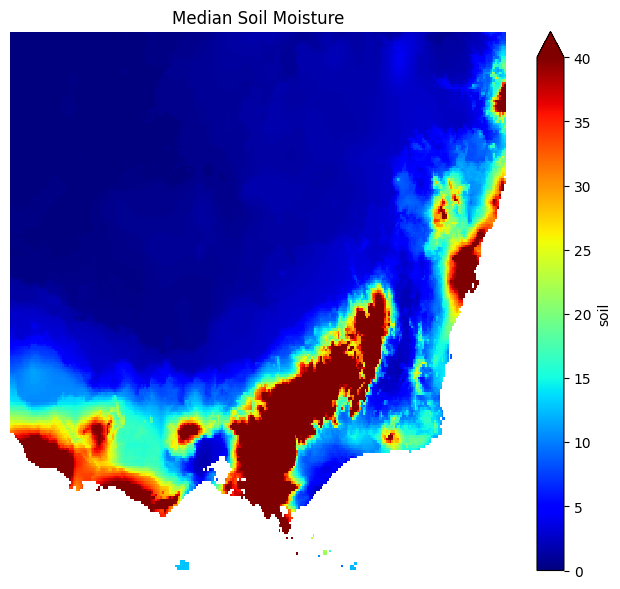

In [43]:
# Plot median soil moisture.
fig, ax = plt.subplots(figsize=(8,7))
soil_median.plot.imshow(vmin=0, vmax=40, cmap="jet")
plt.title("Median Soil Moisture")
plt.axis('off')
plt.show()

In [23]:
# Persist dataset in memory.
ds=ds.persist()

In [44]:
# Compute median along time dimension.
median = ds.median(dim="time", skipna=True).compute()

### Save the output data in a GeoTIFF file
The output product only contains 2 selected parameters that are used in the benchmark notebook. Participants may choose to include all of the parameters for their models to investigate how different parameters change their model results.

In [45]:
#Define output file name.
filename = "TerraClimate_output.tiff"

In [46]:
# Calculate the dimensions of the file
height = median.dims["lat"]
width = median.dims["lon"]

In [48]:
# # Define the Coordinate Reference System (CRS) to be common Lat-Lon coordinates
# # Define the tranformation using our bounding box so the Lat-Lon information is written to the GeoTIFF
gt = rasterio.transform.from_bounds(min_lon,min_lat,max_lon,max_lat,width,height)
median.rio.write_crs("epsg:4326", inplace=True)
median.rio.write_transform(transform=gt, inplace=True);


In [49]:
# Create the GeoTIFF output file using the defined parameters
with rasterio.open(filename,'w',driver='GTiff',width=width,height=height,
                   crs='epsg:4326',transform=gt,count=2,compress='lzw',dtype='float64') as dst:
    dst.write(median.srad,1)
    dst.write(median.vap,2)

In [29]:
# Show the location and size of the new output file
!ls *.tiff

TerraClimate_output.tiff
